In [4]:
# Clone the (private) repository and install it. Colab only; locally this cell just
# points sys.path at the checkout.
#
# Access: add a GitHub token as a Colab secret named GITHUB_TOKEN (key icon in the left
# sidebar, notebook access on). It is read from there and never printed or stored in
# the clone's git config.
import os
import subprocess
import sys

REPO = "github.com/AndreaKarlova/interpret_tfm.git"
BRANCH = "main"
IN_COLAB = "google.colab" in sys.modules


def git(*args, token=None):
    """Run git; on failure, raise without echoing the token-bearing command."""
    result = subprocess.run(["git", *args], capture_output=True, text=True)
    if result.returncode != 0:
        message = result.stderr.replace(token, "***") if token else result.stderr
        raise RuntimeError(f"git {args[0]} failed:\n{message}")


if IN_COLAB:
    from google.colab import drive, userdata

    REPO_DIR = "/content/interpret_tfm"
    token = userdata.get("GITHUB_TOKEN")
    authed = f"https://x-access-token:{token}@{REPO}"
    if not os.path.isdir(REPO_DIR):
        git("clone", "-q", "-b", BRANCH, authed, REPO_DIR, token=token)
        git("-C", REPO_DIR, "remote", "set-url", "origin", f"https://{REPO}")
    else:
        git("-C", REPO_DIR, "pull", "-q", authed, BRANCH, token=token)
    del token, authed

    # Installs kernel_louis and the KernelICL fork of tabicl, plus their dependencies.
    # Never `pip install tabicl` on top: the PyPI package would shadow the fork.
    !pip install -q -e {REPO_DIR}

    drive.mount("/content/drive")
    PAPER_PT = "/content/drive/MyDrive/kernelicl/paper.pt"   # where kernelicl_finetune wrote it
else:
    REPO_DIR = os.path.abspath("..")       # running from interpret_tfm/notebooks
    PAPER_PT = os.path.expanduser("~/Downloads/paper.pt")

# An editable install only takes effect after a runtime restart, so put the sources on
# the path directly as well. kernelicl/ holds the pasteable scripts, including
# kernelicl_diagnostics.py.
for path in (os.path.join(REPO_DIR, "kernelicl"), os.path.join(REPO_DIR, "src"), REPO_DIR):
    if path not in sys.path:
        sys.path.insert(0, path)

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for interpret_tfm (pyproject.toml) ... done
Mounted at /content/drive


In [5]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from kernelicl_diagnostics import KernelICLPredictor, load_kernelicl

# "refit" drops each context row and re-runs the whole model (n forward passes, ~1 s here).
# "frozen" only drops the kernel's self-weight, but every context embedding has already
# absorbed its own label, so L_i comes out ~0 for almost every point. See the last cell.
LOO_MODE = "refit"

X_, y_ = make_classification(n_samples=60, n_features=6, n_informative=4,
                             n_redundant=0, n_classes=2, random_state=0)
X_ctx, X_eval, y_ctx, y_eval = train_test_split(X_, y_, test_size=0.2, random_state=0)

def fit_pca(H, k=2):
    mean = H.mean(0)
    _, _, Vt = np.linalg.svd(H - mean, full_matrices=False)
    return mean, Vt[:k]

def apply_pca(H, mean, comps):
    return (H - mean) @ comps.T

In [6]:
model = load_kernelicl(PAPER_PT)     # kernel="knn" swaps the kernel at evaluation, as in §4.1
model

KernelICL(from=tabicl-classifier-v2-20260212.ckpt, kernel=gaussian, gamma=0.022097086912079608, d_model=512, d_k=512, val_loss=0.7000)

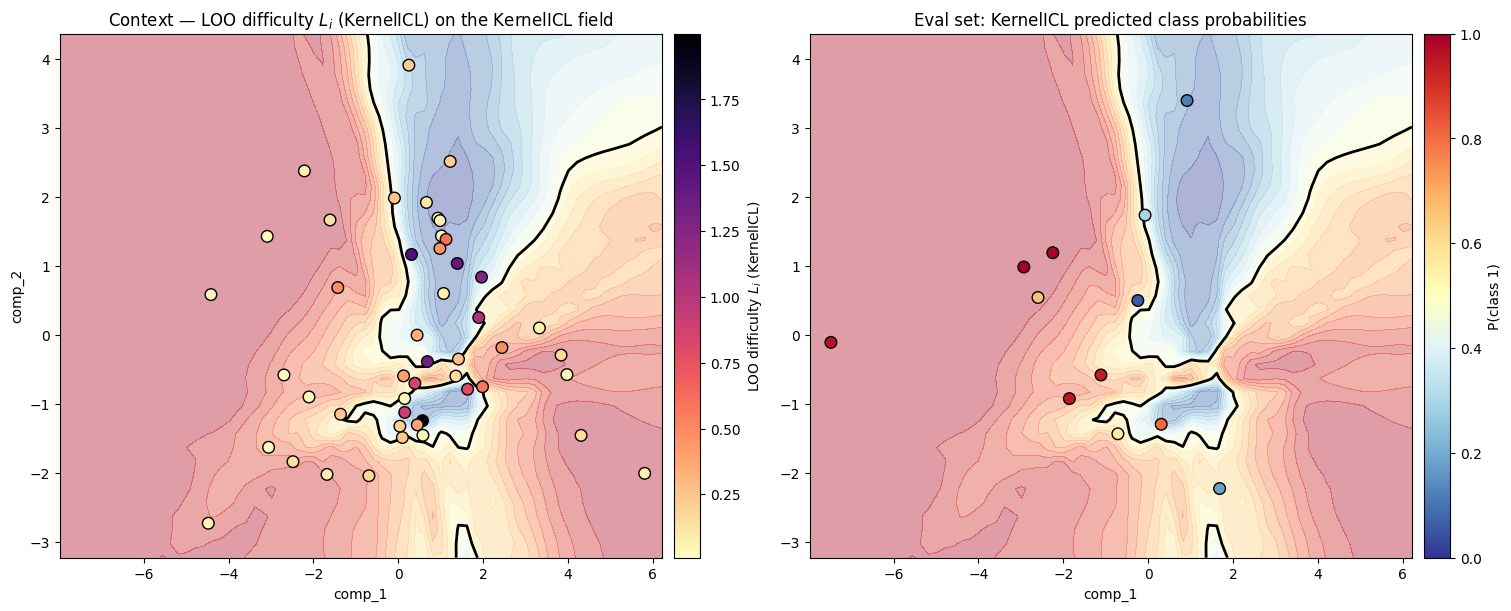

In [7]:
# ===== Context scored by LOO difficulty, drawn on the KernelICL probability map =====
# Everything from the TRAINED KernelICL: embeddings + kernel for L_i, and the predictions
# for the field and eval. Needs the cells above: model, X_, X_ctx, y_ctx, X_eval,
# fit_pca, apply_pca, and KernelICLPredictor.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

pred = KernelICLPredictor(model, X_ctx, y_ctx)        # wrap the trained KernelICL for a fixed context

# ---- score the context with KernelICL's own weights ----
L = pred.context_difficulty(mode=LOO_MODE)            # L_i = -log p^{-i}(y_i)

# ---- KernelICL probability field ----
mean, comp = fit_pca(X_)
x_2d = apply_pca(X_, mean, comp)
ctx_2d = apply_pca(X_ctx, mean, comp)
eval_2d = apply_pca(X_eval, mean, comp)
hgrid, offset = 0.2, 0.5
x_min, x_max = x_2d[:, 0].min() - offset, x_2d[:, 0].max() + offset
y_min, y_max = x_2d[:, 1].min() - offset, x_2d[:, 1].max() + offset
xx, yy = np.meshgrid(np.arange(x_min, x_max, hgrid), np.arange(y_min, y_max, hgrid))
grid = np.c_[xx.ravel(), yy.ravel()] @ comp + mean
Z = pred.predict_proba(grid)[:, 1].reshape(xx.shape)  # <- KernelICL vote

# ---- plot: KernelICL field in both panels; left coloured by KernelICL difficulty ----
fig, ax = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
for a in ax:
    a.contourf(xx, yy, Z, levels=20, cmap="RdYlBu_r", alpha=0.4)
    a.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)

sc = ax[0].scatter(ctx_2d[:, 0], ctx_2d[:, 1], c=L, cmap="magma_r",
                   edgecolors="k", s=70, zorder=3)
ax[0].set_title(r"Context — LOO difficulty $L_i$ (KernelICL) on the KernelICL field")
fig.colorbar(sc, ax=ax[0], label=r"LOO difficulty $L_i$ (KernelICL)", fraction=0.046, pad=0.02)

p_eval = pred.predict_proba(X_eval)[:, 1]
ax[1].scatter(eval_2d[:, 0], eval_2d[:, 1], c=p_eval, cmap="RdYlBu_r", norm=Normalize(0, 1),
              edgecolors="k", s=70, zorder=3)
ax[1].set_title("Eval set: KernelICL predicted class probabilities")
fig.colorbar(ScalarMappable(Normalize(0, 1), "RdYlBu_r"), ax=ax[1],
             label="P(class 1)", fraction=0.046, pad=0.02)

ax[0].set(xlabel="comp_1", ylabel="comp_2"); ax[1].set(xlabel="comp_1")
plt.show()

In [8]:
# Sanity checks: accuracy against the same backbone read through its MLP decoder, and
# how far the free (frozen) LOO score is from the real one.
from scipy.stats import spearmanr

acc_kernel = (pred.predict(X_eval) == y_eval).mean()
acc_mlp = (pred.clf.predict(X_eval) == y_eval).mean()
L_frozen = pred.context_difficulty(mode="frozen")
L_refit = L if LOO_MODE == "refit" else pred.context_difficulty(mode="refit")

print(f"eval accuracy    kernel head {acc_kernel:.3f}   MLP decoder {acc_mlp:.3f}   (n={len(y_eval)})")
print(f"L_i frozen       median {np.median(L_frozen):.3f}   max {L_frozen.max():.3f}")
print(f"L_i refit        median {np.median(L_refit):.3f}   max {L_refit.max():.3f}")
print(f"rank agreement   Spearman {spearmanr(L_frozen, L_refit)[0]:.3f}")

eval accuracy    kernel head 0.667   MLP decoder 0.750   (n=12)
L_i frozen       median 0.008   max 0.072
L_i refit        median 0.193   max 2.000
rank agreement   Spearman 0.926
